C:\Users\DELL\AppData\Local\Temp\ipykernel_31508\3707320819.py:12: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False, na_values=['nan','?'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_31508\3707320819.py:12: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False, na_values=['nan','?'])


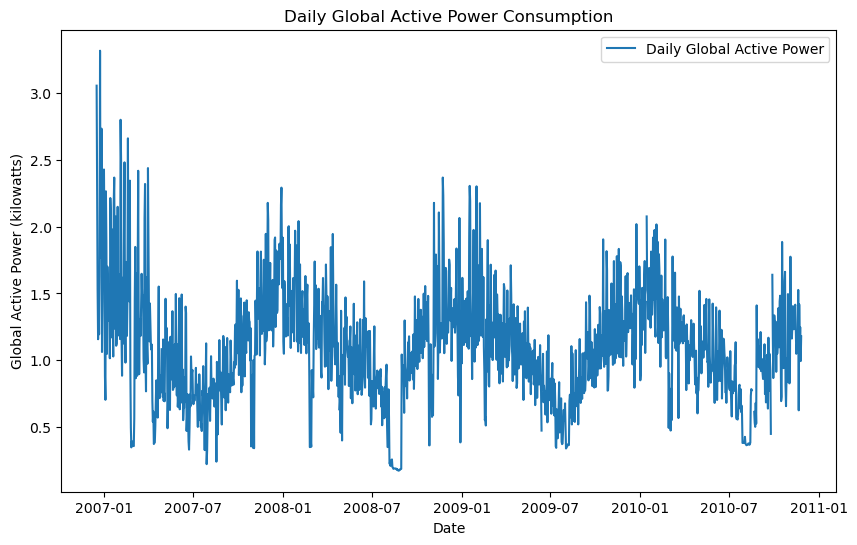

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Load the dataset from the extracted local path
file_path = 'C:\\Users\\DELL\\Downloads\\UCI dataset\\household_power_consumption.txt'  # Replace with your path

# Load the data into a pandas DataFrame
data = pd.read_csv(file_path, sep=';', parse_dates={'datetime': ['Date', 'Time']}, infer_datetime_format=True, low_memory=False, na_values=['nan','?'])

# Handle missing values by dropping rows with NaN values
data.dropna(inplace=True)

# Convert the Global_active_power column to float
data['Global_active_power'] = data['Global_active_power'].astype(float)

# Set datetime as the index
data.set_index('datetime', inplace=True)

# Resample data to daily averages
daily_data = data.resample('D').mean()

# Plot the daily power consumption
plt.figure(figsize=(10, 6))
plt.plot(daily_data['Global_active_power'], label='Daily Global Active Power')
plt.title('Daily Global Active Power Consumption')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kilowatts)')
plt.legend()
plt.show()


In [3]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(daily_data[['Global_active_power']])


In [4]:
def create_sequences(data, time_step):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

time_step = 30  # Number of past days to use for prediction
X, y = create_sequences(scaled_data, time_step)


In [5]:
# Reshape input to be [samples, features]
X = X.reshape(X.shape[0], X.shape[1])

# Split the data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]


In [6]:
# Build the MLP model
model = Sequential()

# Add input layer
model.add(Dense(units=128, activation='relu', input_shape=(X_train.shape[1],)))

# Add hidden layers with dropout for regularization
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

# Add output layer
model.add(Dense(units=1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: nan - val_loss: nan
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan - val_loss: nan
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 12/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: nan - val_loss: nan
Epoch 13/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: na

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


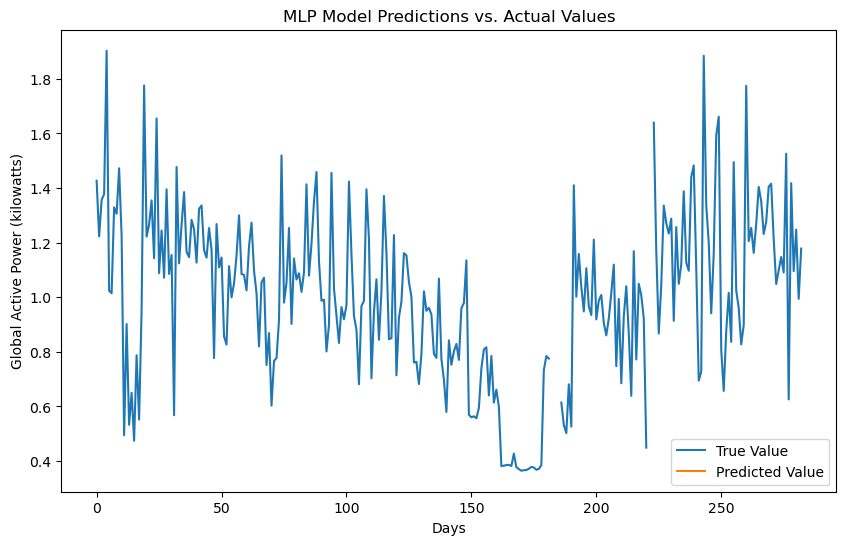

In [8]:
# Make predictions
y_pred = model.predict(X_test)

# Inverse transform the predictions and actual values
y_pred = scaler.inverse_transform(y_pred)
y_test = scaler.inverse_transform(y_test)

# Plot the predictions and actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Value')
plt.plot(y_pred, label='Predicted Value')
plt.title('MLP Model Predictions vs. Actual Values')
plt.xlabel('Days')
plt.ylabel('Global Active Power (kilowatts)')
plt.legend()
plt.show()


In [9]:
model.save('mlp_power_consumption.h5')

# To load the model:
# from tensorflow.keras.models import load_model
# model = load_model('mlp_power_consumption.h5')


In [12]:
# Check for NaN values in y_test and y_pred
print(f"Number of NaN in y_test: {np.isnan(y_test).sum()}")
print(f"Number of NaN in y_pred: {np.isnan(y_pred).sum()}")





Number of NaN in y_test: 6
Number of NaN in y_pred: 283


In [13]:
# Reshape y_test and y_pred to ensure correct shape before inverse transforming
y_test = y_test.reshape(-1, 1)
y_pred = y_pred.reshape(-1, 1)

# Inverse transform
y_test = scaler.inverse_transform(y_test)
y_pred = scaler.inverse_transform(y_pred)


In [14]:
# Replace NaN values with 0 (or you can use other strategies)
y_test = np.nan_to_num(y_test)
y_pred = np.nan_to_num(y_pred)


In [15]:
from sklearn.metrics import mean_squared_error

# Recalculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error: {rmse}')


Root Mean Squared Error: 3.408237897583166
